# Netflix Titles — Data Cleaning & Exploratory Data Analysis (EDA)

**Goal of this notebook:**
1. Load the raw Netflix dataset (`netflix_titles.csv` from Kaggle)
2. Clean it (nulls, duplicates, dates, text formatting)
3. Engineer a few useful new columns
4. Save a clean CSV (`netflix_cleaned.csv`) — this is what you'll later upload to S3
5. Run EDA and save chart images for your README / dashboard

Every cell below has comments explaining exactly what it does, so you can also use this as a
reference/checklist for your portfolio write-up.


## 1. Import Libraries

In [3]:
# Core data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# For creating output folders
import os

# Make plots look clean by default
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Create a folder to save all EDA chart images (used later for README/dashboard)
os.makedirs("charts", exist_ok=True)


## 2. Load the Dataset

Download `netflix_titles.csv` from Kaggle
(search "Netflix Movies and TV Shows" dataset) and place it in the **same folder** as this
notebook, or update the path below.


In [5]:
# Path to the raw dataset — change this if your file is somewhere else
RAW_DATA_PATH = "netflix_titles.csv"

# Load the CSV into a pandas DataFrame
df = pd.read_csv(RAW_DATA_PATH)

# Quick look at the first few rows to confirm it loaded correctly
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
# Basic shape and structure of the dataset (rows, columns)
print("Shape of dataset:", df.shape)

# Column names, data types, and non-null counts — helps spot missing data quickly
df.info()


Shape of dataset: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## 3. Initial Inspection — Missing Values & Duplicates

In [8]:
# Count of missing (NaN) values per column, sorted from most to least
missing_counts = df.isnull().sum().sort_values(ascending=False)

# Percentage of missing values per column (easier to interpret than raw counts)
missing_percent = (missing_counts / len(df) * 100).round(2)

# Combine both into a single summary table
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_percent
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


In [9]:
# Check how many fully duplicated rows exist in the dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


## 4. Data Cleaning

We'll now clean the dataset step by step:
- Drop exact duplicate rows
- Handle missing values in key columns (`country`, `director`, `cast`, `rating`, `date_added`)
- Convert `date_added` to a proper datetime type
- Standardize text columns (trim whitespace, consistent casing where useful)


In [11]:
# --- 4.1 Remove exact duplicate rows ---
before_rows = len(df)
df = df.drop_duplicates()
after_rows = len(df)

print(f"Removed {before_rows - after_rows} duplicate rows.")
print(f"Rows remaining: {after_rows}")


Removed 0 duplicate rows.
Rows remaining: 8807


In [12]:
# --- 4.2 Handle missing values in key text columns ---
# For columns like 'director', 'cast', and 'country', a missing value usually just means
# "not listed" rather than a data error, so we fill with a clear placeholder instead of
# dropping the row (dropping would lose a lot of useful data in other columns).

df["director"] = df["director"].fillna("Not Given")
df["cast"] = df["cast"].fillna("Not Given")
df["country"] = df["country"].fillna("Not Given")

# 'rating' is usually only missing for a handful of rows — fill with "Not Rated"
df["rating"] = df["rating"].fillna("Not Rated")

# 'duration' missing rows are rare edge cases — fill with "Not Given" so dtype stays consistent
df["duration"] = df["duration"].fillna("Not Given")


In [13]:
# --- 4.3 Handle missing 'date_added' ---
# 'date_added' tells us when the title was added to Netflix's catalog.
# If it's missing, we can't reliably impute a date, so we drop only those rows
# (this is usually a very small fraction of the dataset).

before_rows = len(df)
df = df.dropna(subset=["date_added"])
after_rows = len(df)

print(f"Dropped {before_rows - after_rows} rows with missing date_added.")


Dropped 10 rows with missing date_added.


In [14]:
# --- 4.4 Convert 'date_added' to datetime ---
# The raw column looks like "September 25, 2021" (string) — convert it to a real datetime
# object so we can extract year/month and sort/filter by date properly.

df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format="mixed")

# Confirm the conversion worked
df["date_added"].head()


0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [15]:
# --- 4.5 Standardize text columns ---
# Trim leading/trailing whitespace from all text (object) columns.
# Netflix's raw CSV sometimes has stray spaces after commas in 'country' or 'listed_in'.

text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()

# 'type' should just be "Movie" or "TV Show" — standardize casing just in case
df["type"] = df["type"].str.title()


## 5. Feature Engineering

We'll create a few new columns that make later SQL/EDA/dashboard work much easier:
- `year_added`, `month_added` — extracted from `date_added`
- `movie_duration_minutes` — numeric minutes (only applies to Movies)
- `tv_seasons` — numeric season count (only applies to TV Shows)
- `primary_country` — the first country listed (since `country` can have multiple, comma-separated)
- `primary_genre` — the first genre listed (since `listed_in` can have multiple, comma-separated)


In [17]:
# --- 5.1 Extract year and month from date_added ---
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()


In [18]:
# --- 5.2 Split 'duration' into numeric minutes (Movies) and seasons (TV Shows) ---
# 'duration' looks like "90 min" for movies or "3 Seasons" for TV shows.
# We extract just the numeric part using a regex and store it in two separate columns
# so each stays numeric and analysis-ready (instead of one mixed-meaning column).

duration_numeric = df["duration"].str.extract(r"(\d+)").astype(float)

df["movie_duration_minutes"] = np.where(df["type"] == "Movie", duration_numeric[0], np.nan)
df["tv_seasons"] = np.where(df["type"] == "Tv Show", duration_numeric[0], np.nan)


In [19]:
# --- 5.3 Extract primary (first-listed) country and genre ---
# 'country' and 'listed_in' can contain multiple comma-separated values
# (e.g. "United States, India"). For simple bar-chart-style analysis we usually want
# just the FIRST/primary one, while still keeping the original full column for reference.

df["primary_country"] = df["country"].str.split(",").str[0].str.strip()
df["primary_genre"] = df["listed_in"].str.split(",").str[0].str.strip()


In [20]:
# Sanity check — view the newly engineered columns
df[["title", "type", "date_added", "year_added", "month_added",
    "movie_duration_minutes", "tv_seasons", "primary_country", "primary_genre"]].head()


,title,type,date_added,year_added,month_added,movie_duration_minutes,tv_seasons,primary_country,primary_genre
0,Dick Johnson Is Dead,Movie,2021-09-25,2021,September,90.0,NaN,United States,Documentaries
1,Blood & Water,Tv Show,2021-09-24,2021,September,NaN,2.0,South Africa,International TV Shows
2,Ganglands,Tv Show,2021-09-24,2021,September,NaN,1.0,Not Given,Crime TV Shows
3,Jailbirds New Orleans,Tv Show,2021-09-24,2021,September,NaN,1.0,Not Given,Docuseries
4,Kota Factory,Tv Show,2021-09-24,2021,September,NaN,2.0,India,International TV Shows


## 6. Save the Cleaned Dataset

This `netflix_cleaned.csv` is the file you'll upload to your S3 `raw/` (or `processed/`) folder
in the AWS phase of the project.


In [22]:
CLEANED_DATA_PATH = "netflix_cleaned.csv"

df.to_csv(CLEANED_DATA_PATH, index=False)

print(f"Cleaned dataset saved to: {CLEANED_DATA_PATH}")
print(f"Final shape: {df.shape}")


Cleaned dataset saved to: netflix_cleaned.csv
Final shape: (8797, 18)


## 7. Exploratory Data Analysis (EDA)

Now that the data is clean, let's answer the key business questions and save chart images
into the `charts/` folder — these are the same PNGs you'll drop into your GitHub README.


### 7.1 Movies vs TV Shows

type
Movie      6131
Tv Show    2666
Name: count, dtype: int64


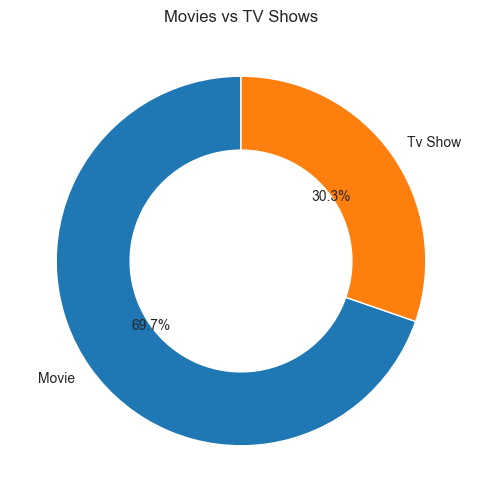

In [25]:
# Count how many Movies vs TV Shows exist in the catalog
type_counts = df["type"].value_counts()
print(type_counts)

# Donut-style chart (pie chart with a hole in the middle)
plt.figure(figsize=(6, 6))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}  # this creates the 'donut' hole
)
plt.title("Movies vs TV Shows")
plt.savefig("charts/movies_vs_tvshows.png", bbox_inches="tight")
plt.show()


### 7.2 Content Growth Over Time

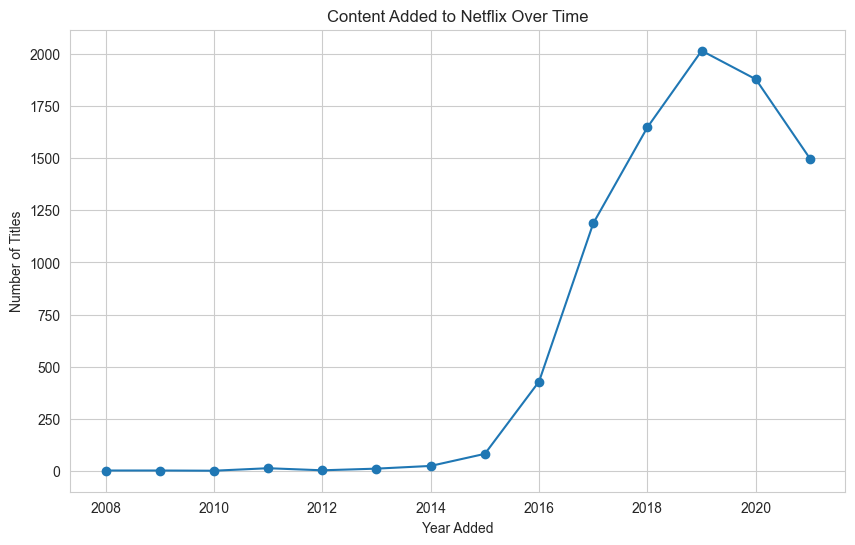

In [27]:
# Count how many titles were added to Netflix per year
content_by_year = df["year_added"].value_counts().sort_index()

plt.figure()
plt.plot(content_by_year.index, content_by_year.values, marker="o")
plt.title("Content Added to Netflix Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.savefig("charts/content_growth_over_time.png", bbox_inches="tight")
plt.show()


### 7.3 Top 10 Countries by Content

C:\Users\muska\AppData\Local\Temp\ipykernel_26512\1283206499.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


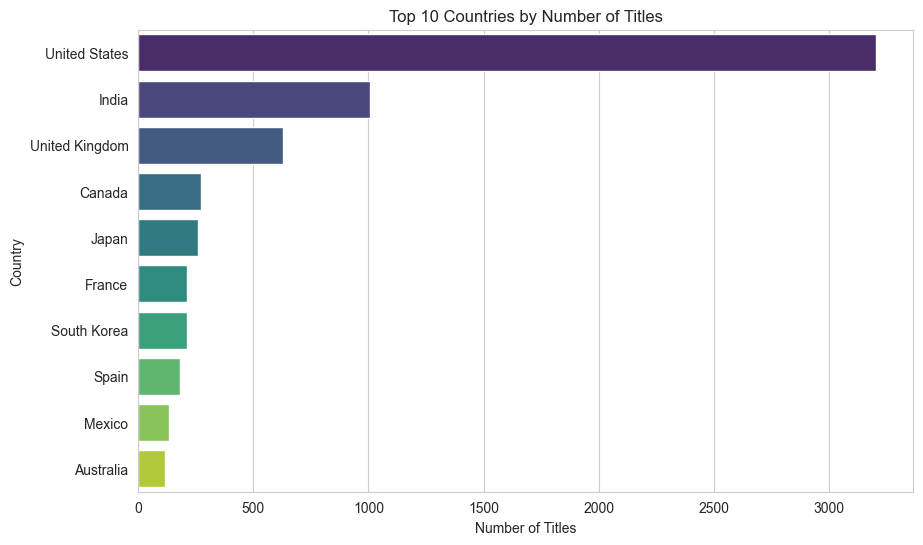

In [29]:
# Which countries produce the most Netflix content? (using primary_country)
top_countries = (
    df[df["primary_country"] != "Not Given"]["primary_country"]
    .value_counts()
    .head(10)
)

plt.figure()
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.savefig("charts/top_10_countries.png", bbox_inches="tight")
plt.show()


### 7.4 Top 10 Genres

C:\Users\muska\AppData\Local\Temp\ipykernel_26512\1579385801.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="magma")


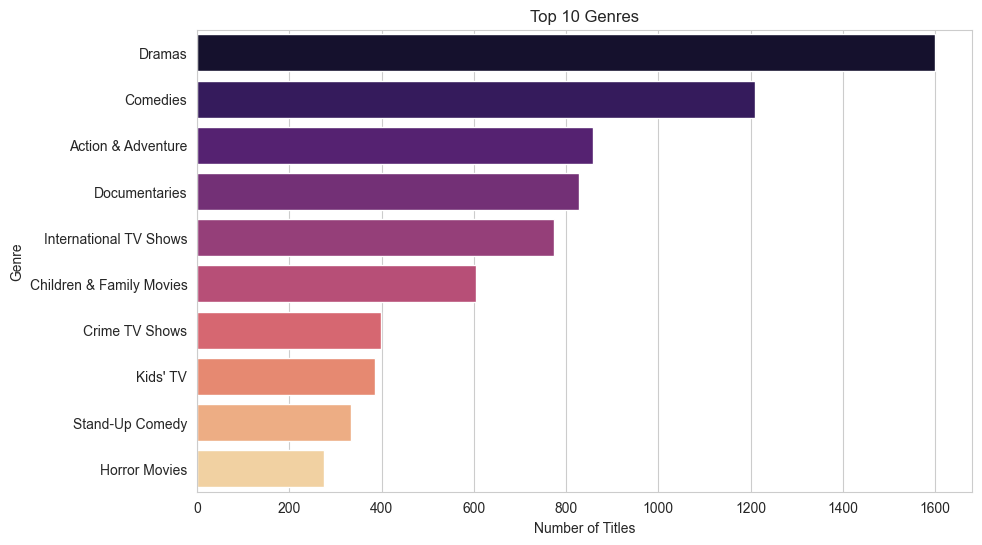

In [31]:
# Which genres appear most often? (using primary_genre)
top_genres = df["primary_genre"].value_counts().head(10)

plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index, palette="magma")
plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.savefig("charts/top_10_genres.png", bbox_inches="tight")
plt.show()


### 7.5 Rating Distribution

C:\Users\muska\AppData\Local\Temp\ipykernel_26512\269219364.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.values, y=rating_counts.index, palette="coolwarm")


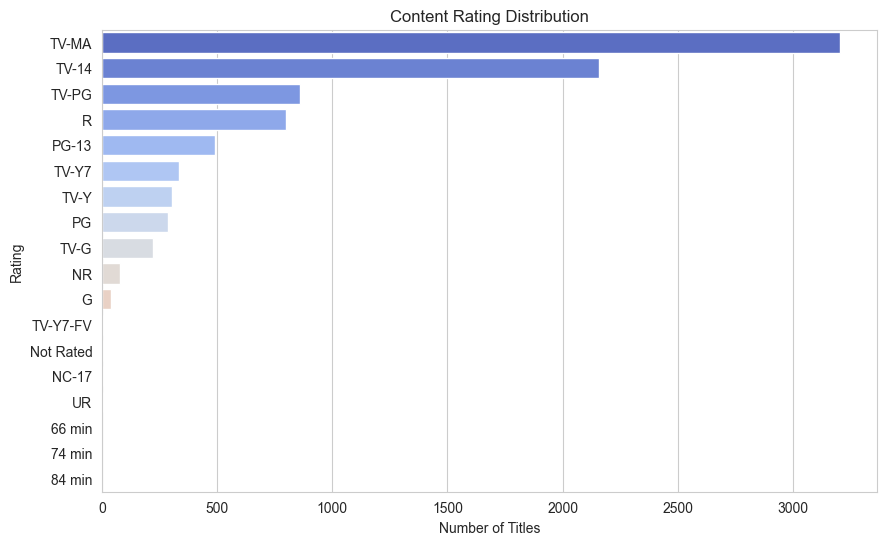

In [33]:
# Distribution of content ratings (TV-MA, PG-13, etc.)
rating_counts = df["rating"].value_counts()

plt.figure()
sns.barplot(x=rating_counts.values, y=rating_counts.index, palette="coolwarm")
plt.title("Content Rating Distribution")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.savefig("charts/rating_distribution.png", bbox_inches="tight")
plt.show()


### 7.6 Movie Duration Distribution

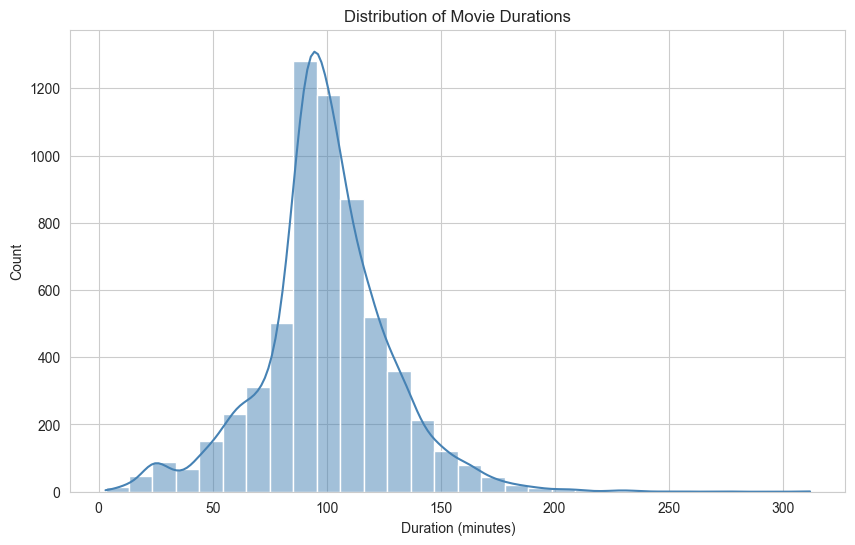

In [35]:
# Histogram showing how long movies typically are (in minutes)
plt.figure()
sns.histplot(df["movie_duration_minutes"].dropna(), bins=30, kde=True, color="steelblue")
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.savefig("charts/movie_duration_distribution.png", bbox_inches="tight")
plt.show()


### 7.7 Top 10 Directors

C:\Users\muska\AppData\Local\Temp\ipykernel_26512\2247395231.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette="cubehelix")


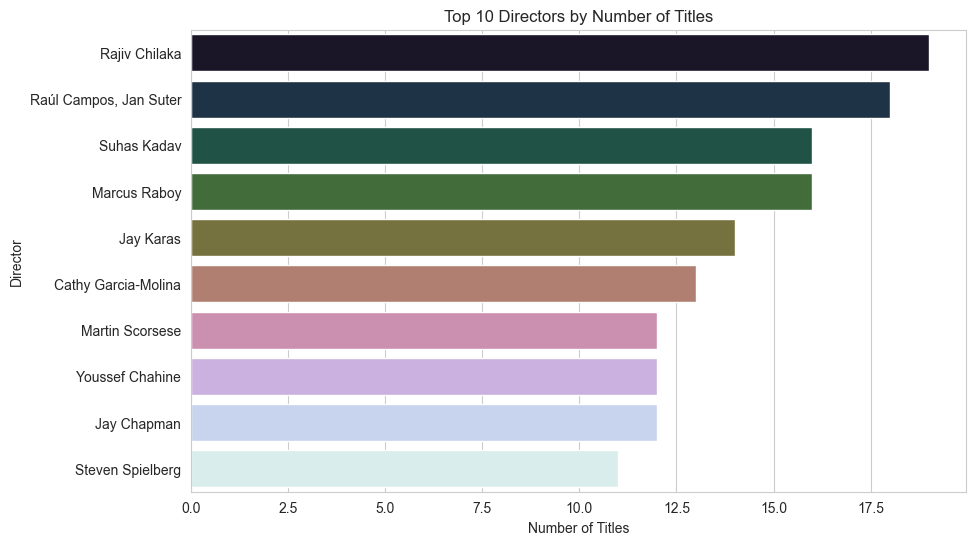

In [39]:
# Which directors have the most titles on Netflix? (excluding 'Not Given')
top_directors = (
    df[df["director"] != "Not Given"]["director"]
    .value_counts()
    .head(10)
)

plt.figure()
sns.barplot(x=top_directors.values, y=top_directors.index, palette="cubehelix")
plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.savefig("charts/top_10_directors.png", bbox_inches="tight")
plt.show()


## 8. Quick Insights Summary

Fill this section in after reviewing the charts above — this becomes the
**Key Insights** section of your README and dashboard. Example prompts:

- Which country contributes the largest share of titles?
- Did content additions peak in a particular year?
- Which rating is most common — what does that say about the target audience?
- Are movies or TV shows growing faster over time?

```
Example:
- The United States contributes the largest share of Netflix titles.
- Content additions peaked around 2019-2020.
- TV-MA is the most common content rating, suggesting a mostly mature-audience catalog.
- Drama and International Movies are the most common genres.
```

**Next steps (outside this notebook):** upload `netflix_cleaned.csv` to S3 → catalog it with
AWS Glue → query it in Athena → build the dashboard in QuickSight.
